### Overview

#### 1.1 Problem Statement

**About Netflix:** Netlfix is one of the most popular media and video streaming platforms. They have over 10,000 Movies or TV-Shows available on their platform, as of mid-2021, they have over 222M Subscribers globally.

**Business Problem:**
Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries. <br><br>

#### 1.2 About Dataset <br>

Features <br>

Lets use the generic word **Content** to represent a Movie or TV Show, hence each row or data-point in the dataset represents an individual content available in Netflix.

The tabular dataset consists of listings of all the contents available on Netflix, described using below list of features:

1. `show_id`: Unique ID for content
2. `type`: Identifier - movie or TV show
3. `title`: Title of content
4. `director`: Director of the movie/TV show
5. `cast`: Actors involved in the Movie/TV show
6. `country`: Country where the Movie/TV show was produced
7. `date_added`: Date it was added to Netflix
8. `release_year`: Actual release year of the Movie/TV show
9. `rating`: TV rating of content
10. `duration`: Length of content (minutes/# of seasons)
11. `listed_in`: Genre
12. `description`: Summary of content <br>

#### 1.3 Objective
Objective of this case study is to perform Exploratory Data Analysis (EDA) on the dataset and attempt to:

1. Extract some business insights
2. Formulate some recommendations based on patterns observed. <br><br>

#### Business Insights <br>

Let's try to derive below business insights from the given dataset: <br>

1. What type of content is available in different countries?
2. How has the number of movies released per year changed over the last 20-30 years?
3. Comparison of TV shows vs. Movies.
4. What is the best time to launch a TV show?
5. Analysis of actors/directors of different types of shows/movies.
6. Does Netflix have more focus on TV Shows that Movies in recent years?
7. Understanding what content is available in different countries. <br><br>

##### Recommendations

Let's try to formulate the below recommendations (if possible) based on the content in the dataset. <br>

1. What should Netflix focus on more between TV Shows and Movies?
2. When is the best time to launch a TV Show?
3. Need for diversification of content globally?

### 2.0 Setup

In [1]:
# Import libraries

import re
import warnings
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [2]:
# Configure Libraries

warnings.filterwarnings(action='ignore')

# Configure Numpy
np.set_printoptions(linewidth=130)

# Configure Pandas
pd.options.display.width = 130

# Configure Seaborn
sns.set_style("whitegrid")
sns.set_palette("deep")
sns.set_context("paper", font_scale=1.2)

In [3]:
# Helped Functions

def display_empty_columns_count(df: pd.DataFrame):
    """
    Function to print columns with missing values greater than zero.
    """
    empty_count_df = df.isna().sum().reset_index(name="count")
    fltr = empty_count_df["count"] > 0
    display(empty_count_df[fltr])


def split_strip_unique(value_str: str):
    """
    Function to sort values in comma separated 'values_str' string
    """
    unq_values = split_strip_unique(values_str)
    return ",".join(sorted(unq_values))


def values_count(values_str: str):
    """
    Function to get value count in 'values_str' string
    """
    return len(values_str.split(","))

#### 2.1 Import Dataset

In [4]:
nf_df = pd.read_csv("C:/Users/GamerTech/Documents/Python/netflix_titles.csv")

row_count, col_count = nf_df.shape

display(nf_df.head(3))
print(f"Dataset has {row_count} rows and {col_count} columns.")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


Dataset has 8807 rows and 12 columns.


#### 2.2 Data Profiling

In [5]:
nf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


*Observations:* <br>

1. Except for the `release_year`, all other features are data-type string.
2. Let's convert `date_added` to Datetime later during the data wrangling phase.
3. `duration` is a string-type and can be converted to integer format.
4. The `rating` feature is a type of string and we will check if it can be converted to integer.

##### Feature Types <br>

1. Categorical Features: `type`, `country`, `rating`, `listed_in`
2. Numerical Features: `date_added`, `release_year`, `duration`
3. High Cardinality Features: `show_id`, `title`, `director`, `cast`, `description` <br><br>

In [6]:
nf_df.nunique().sort_values(ascending=False)

show_id         8807
title           8807
description     8775
cast            7692
director        4528
date_added      1767
country          748
listed_in        514
duration         220
release_year      74
rating            17
type               2
dtype: int64

**Call-Outs:**

1. It's obvious that features like `show_id`,`title`,`director`,`cast` and `description` have high cardinality.
2. Features like `country` and `listed_in` (genre) have unexpectedly high cardinality considering the nature of the dataset's features.

In [7]:
# Empty Check
display_empty_columns_count(nf_df)

,index,count
3,director,2634
4,cast,825
5,country,831
6,date_added,10
8,rating,4
9,duration,3


In [8]:
# Duplicate Check
nf_df[nf_df.duplicated()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


There are no duplicate values.

### 3.0 Data Wrangling

Under data wrangling, I will go through the following steps: <br>

1. Cleaning
2. Formatting
3. Filling/Removing missing values
4. Transforming features
5. Feature engineering <br><br>

##### 3.1 Cleaning

In [9]:
# Feature duration

compact_view = nf_df.columns.drop(["show_id", "description"])

In [10]:
fltr = nf_df["duration"].isna()
nf_df.loc[fltr, compact_view]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
5541,Movie,Louis C.K. 2017,Louis C.K.,Louis C.K.,United States,"April 4, 2017",2017,74 min,NaN,Movies
5794,Movie,Louis C.K.: Hilarious,Louis C.K.,Louis C.K.,United States,"September 16, 2016",2010,84 min,NaN,Movies
5813,Movie,Louis C.K.: Live at the Comedy Store,Louis C.K.,Louis C.K.,United States,"August 15, 2016",2015,66 min,NaN,Movies


In [11]:
ids = [5541, 5794, 5813]
nf_df.loc[ids, "duration"] = nf_df.loc[ids, "rating"]
nf_df.loc[ids, "rating"] = "UR"

In [12]:
# Feature rating
# Different ratings between Movies and TV Shows

print("Unique ratings before cleaning:")
nf_df.groupby("type")["rating"].value_counts()

Unique ratings before cleaning:


type     rating  
Movie    TV-MA       2062
         TV-14       1427
         R            797
         TV-PG        540
         PG-13        490
         PG           287
         TV-Y7        139
         TV-Y         131
         TV-G         126
         NR            75
         G             41
         UR             6
         TV-Y7-FV       5
         NC-17          3
TV Show  TV-MA       1145
         TV-14        733
         TV-PG        323
         TV-Y7        195
         TV-Y         176
         TV-G          94
         NR             5
         R              2
         TV-Y7-FV       1
Name: count, dtype: int64

<br>

1. Since "UR" (Unrated) and "NR" (Not Rated) mean the same thing, we can combine them.
2. "G" (General Audience) and "TV-G" (TV General Audience) represent the same rating, we can combine them as well.
3. "NC-17" (strictly 18+) and "MA" (Mature) mean the same, meaning we combine them too. Same for "TV-Y7-FV" and "TV-Y7".

In [13]:
nf_df["rating"] = nf_df["rating"].replace(
    {
        "UR": "NR",
        "G": "TV-G",
        "NC-17": "TV-MA",
        "TV-Y7-FV": "TV-Y7"
    }
)

print("Unique ratings after cleaning:")
nf_df.groupby("type")["rating"].value_counts() 

Unique ratings after cleaning:


type     rating
Movie    TV-MA     2065
         TV-14     1427
         R          797
         TV-PG      540
         PG-13      490
         PG         287
         TV-G       167
         TV-Y7      144
         TV-Y       131
         NR          81
TV Show  TV-MA     1145
         TV-14      733
         TV-PG      323
         TV-Y7      196
         TV-Y       176
         TV-G        94
         NR           5
         R            2
Name: count, dtype: int64

##### 3.2 Formatting

In [14]:
# Feature country

ctry_card_bfr = nf_df["country"].nunique()
print("Cardinality of `country` before formatting: ", ctry_card_bfr)

Cardinality of `country` before formatting:  748


<br> Sort countries in comma separated string

In [15]:
nf_df["country"] = nf_df["country"].dropna().apply(lambda x: ", ".join(sorted(x.replace(" ", "").split(","))))

ctry_card_aft = nf_df["country"].nunique()
print("Cardinality of `country` after formatting: ", ctry_card_aft)

Cardinality of `country` after formatting:  612


<br> After reformatting the `country` column, we've reduced the cardinality from 748 to 612 countries. <br>

In [16]:
# Feature director

dir_card_bfr = nf_df["director"].nunique()
print("Cardinality of `director` before formatting:", dir_card_bfr)

Cardinality of `director` before formatting: 4528


Sort directors in comma separated director names

In [17]:
nf_df["director"] = nf_df["director"].dropna().apply(lambda x: ", ".join(sorted(x.replace(" ", "").split(","))))

dir_card_aft = nf_df["director"].nunique()
print("Cardinality of `director` after formatting:", dir_card_aft)

Cardinality of `director` after formatting: 4513


<br> After formatting, the director count in the `directors` column has been reduced from 4528 to 4513.

In [18]:
# Feature cast

cast_card_bfr = nf_df["cast"].nunique()
print("Cardinality of `cast` before formatting:", cast_card_bfr)

Cardinality of `cast` before formatting: 7692


In [19]:
# Sort actors in comma separated cast names

nf_df["cast"] = nf_df["cast"].dropna().apply(lambda x: ", ".join(sorted(x.replace(" ", "").split(","))))

cast_card_aft = nf_df["cast"].nunique()
print("Cardinality of `cast` after formatting:", cast_card_aft)

Cardinality of `cast` after formatting: 7678


After reformatting, the actors in the `cast` column has been reduced from 7692 to 7678. <br><br>

##### 3.3 Missing Values

In [20]:
# Check missing values for rating

rat_mis_bfr = nf_df["rating"].isna().sum().item()
print(f"{rat_mis_bfr} records are missing from `rating` before attempting to fill with NA.")

4 records are missing from `rating` before attempting to fill with NA.


In [21]:
# Fill the missing values for rating

rat_mode_df = (
    nf_df.groupby(["type", "listed_in"])["rating"]
    .agg(lambda r_val: r_val.mode().iloc[0])
    .reset_index()
)

rat_merged_df = nf_df.merge(
    rat_mode_df,
    left_on = ["type", "listed_in"],
    right_on = ["type", "listed_in"],
    how = "left",
)

nf_df["rating"] = nf_df["rating"].fillna(rat_merged_df["rating_y"])

rat_mis_aft = nf_df["rating"].isna().sum().item()
print(f"{rat_mis_aft} records are missing from `rating` after filling with NA.")

0 records are missing from `rating` after filling with NA.


In [22]:
# Missing data for date_added column

da_mis_bfr = nf_df["date_added"].isna().sum().item()
print(f"{da_mis_bfr} records are missing from `date_added` before attempting to fill with NA.")

10 records are missing from `date_added` before attempting to fill with NA.


In [23]:
# Fill the missing values for date_added

da_mode_df = (
    nf_df.groupby(["country", "type", "release_year"])["date_added"].agg(lambda da_val: da_val.mode().iloc[0]).reset_index()
)

da_merged_df = nf_df.merge(
    da_mode_df,
    left_on = ["country", "type", "release_year"],
    right_on = ["country", "type", "release_year"],
    how = "left"
)

nf_df["date_added"] = nf_df["date_added"].fillna(da_merged_df["date_added_y"])

da_mis_aft = nf_df["date_added"].isna().sum().item()
print(f"{da_mis_aft} record is missing in `date_added` after filling with NA.")

1 record is missing in `date_added` after filling with NA.


In [24]:
fltr = nf_df["date_added"].isna()
nf_df.loc[fltr, compact_view]

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
7196,TV Show,Kikoriki,NaN,IgorDmitriev,NaN,NaN,2010,TV-Y,2 Seasons,Kids' TV


Not only is this row missing the `date_added` value, but it's also missing information for `country` and `director`. I have decided to keep this row going forward.

In [25]:
# Check missing values for country column

ctry_mis_bfr = nf_df["country"].isna().sum().item()
print(f"{ctry_mis_bfr} records are missing from the `country` column before attempting to fill with NA.")

831 records are missing from the `country` column before attempting to fill with NA.


In [26]:
# Fill the missing values for country

fltr = nf_df["country"].notna()
ctry_mode_df = (
    nf_df[fltr].groupby("director")["country"].agg(lambda ctry_str: ctry_str.mode().iloc[0]).reset_index()
)

ctry_merged_df = nf_df.merge(
    ctry_mode_df,
    left_on = ["director"],
    right_on = ["director"],
    how="left",
)

nf_df["country"] = nf_df["country"].fillna(ctry_merged_df["country_y"])

ctry_mis_aft = nf_df["country"].isna().sum().item()
print(f"{ctry_mis_aft} records are missing `country` after filling with NA.")

681 records are missing `country` after filling with NA.


Let's fill missing `country` from most common country for which a director has produced the content.

In [27]:
fltr = nf_df["country"].notna()
ctry_mode_df = (
    nf_df[fltr].groupby("director")["country"].agg(lambda ctry_str: ctry_str.mode().iloc[0]).reset_index()
)

ctry_merged_df = nf_df.merge(
    ctry_mode_df,
    left_on = ["director"],
    right_on = ["director"],
    how = "left"
)

nf_df["country"] = nf_df["country"].fillna(ctry_merged_df["country_y"])

ctry_miss_aft = nf_df["country"].isna().sum().item()
print(f"{ctry_mis_aft} records are missing 'country' after attempting to fill NA.")

681 records are missing 'country' after attempting to fill NA.


##### 4. Feature Director

In [28]:
dir_na_count = nf_df["director"].isna().sum().item()
dir_na_per = round(dir_na_count / len(nf_df) * 100)

print(f"Missing count: {dir_na_count} Missing percentage: {dir_na_per}%")

Missing count: 2634 Missing percentage: 30%


1. Feature director is missing 2,634 values.
2. ~30% of rows are missing director feature.
3. It is not sensible to fill missing values using imputation techniques.
4. Better approach is to fill missing data by Web Scraping.

##### 5. Feature Cast

In [29]:
cst_na_count = nf_df["cast"].isna().sum().item()
cst_na_per = round(cst_na_count / len(nf_df) * 100)

print(f"Missing count: {cst_na_count} Missing percentage: {cst_na_per}%")

Missing count: 825 Missing percentage: 9%


Feature cast is missing 825 values. Approximately, 9% of rows are missing cast feature. It is not sensible to fill missing values using imputation techniques. Better approach is to fill missing data by Web Scraping.

Final result after filling missing values

In [30]:
display_empty_columns_count(nf_df)

,index,count
3,director,2634
4,cast,825
5,country,681
6,date_added,1


#### 3.4 Transforming

##### 1. Feature Type

In [31]:
# nf_df["type"] = nf_df["type"].astype("category")
# nf_df["type"].info()

**Note:** Code is commented out because it's affecting grouping in later stages.

##### 2. Feature `date_added`

Convert `date_added` from string to datetime data type.

In [32]:
nf_df["date_added"].sample(2)

1635    November 27, 2020
3385     October 23, 2019
Name: date_added, dtype: object

In [33]:
nf_df["date_added"] = pd.to_datetime(nf_df["date_added"].str.strip(), format="%B %d, %Y")
nf_df["date_added"].sample(3)

4851   2018-05-25
8776   2015-08-05
6109   2017-07-01
Name: date_added, dtype: datetime64[ns]

#### 3.5 Data Validation

##### 1. Feature `date_added` and `release_year`

In [34]:
fltr = nf_df["release_year"] > nf_df["date_added"].dt.year
nf_df.loc[fltr, ["type", "title", "release_year", "date_added", "country"]]

,type,title,release_year,date_added,country
1551,TV Show,Hilda,2021,2020-12-14,"Canada, UnitedKingdom, UnitedStates"
1696,TV Show,Polly Pocket,2021,2020-11-15,"Canada, Ireland, UnitedStates"
2920,TV Show,Love Is Blind,2021,2020-02-13,UnitedStates
3168,TV Show,Fuller House,2020,2019-12-06,UnitedStates
3287,TV Show,Maradona in Mexico,2020,2019-11-13,"Argentina, Mexico, UnitedStates"
3369,TV Show,BoJack Horseman,2020,2019-10-25,UnitedStates
3433,TV Show,The Hook Up Plan,2020,2019-10-11,France
4844,TV Show,Unbreakable Kimmy Schmidt,2019,2018-05-30,UnitedStates
4845,TV Show,Arrested Development,2019,2018-05-29,UnitedStates
5394,Movie,Hans Teeuwen: Real Rancour,2018,2017-07-01,Netherlands


**Observations:** There are 14 rows that have `release_year` greater than streaming year `date_added`, which is not possible since Netflix cannot stream content before its release.

In [35]:
nf_df.loc[fltr, "release_year"] = nf_df.loc[fltr, "date_added"].dt.year

#### 3.6 Feature Engineering

##### 1. Feature `content_level`

In [36]:
nf_df["rating"].value_counts()

rating
TV-MA    3210
TV-14    2161
TV-PG     863
R         800
PG-13     490
TV-Y7     341
TV-Y      308
PG        287
TV-G      261
NR         86
Name: count, dtype: int64

This rating system us used in the US and UK, but other countries follow a much simpler rating system with fewer categories. 

In [37]:
rating_to_level_map = {
    "TV-G": "Kid-Friendly",
    "TV-Y": "Kid-Friendly",
    "TV-Y7": "Kid-Friendly",
    "PG": "General-Audience",
    "TV-14": "General-Audience",
    "TV-PG": "General-Audience",
    "PG-13": "General-Audience",
    "TV-MA": "Adult-Content",
    "R": "Adult-Content",
}

nf_df["content_level"] = nf_df["rating"].map(rating_to_level_map).astype("category")
nf_df["content_level"].value_counts()

content_level
Adult-Content       4010
General-Audience    3801
Kid-Friendly         910
Name: count, dtype: int64

##### 2. Feature `duration_in_min`

In [38]:
nf_df["duration"].sample(3)

6670      105 min
7406    4 Seasons
6699       93 min
Name: duration, dtype: object

Segregate duration in minutes from `duration` feature.

In [39]:
def duration_in_min(duration_str):
    """
    Function to extract duration in minutes from `duration` feature.
    """
    match = re.match(r"^(\d+)\s+(min)$", duration_str, flags = re.IGNORECASE)
    return match.group(1) if match else -1

nf_df["duration_in_min"] = nf_df["duration"].apply(duration_in_min).astype(int)

In [40]:
fltr = nf_df["duration_in_min"] != -1
nf_df.loc[fltr, "duration_in_min"].sample(3)

8260     66
1409    115
3347    141
Name: duration_in_min, dtype: int64

##### 3. Feature `duration_in_ssn`

Segregate season sount from `duration` feature.

In [41]:
def duration_in_ssn(duration_str):
    """
    Function to extract season count from `duration` feature.
    """
    match = re.search(r"^(\d+)\s+(seasons?)$", duration_str, flags=re.IGNORECASE)
    return match.group(1) if match else -1


nf_df["duration_in_ssn"] = nf_df["duration"].apply(duration_in_ssn).astype(int)

In [42]:
fltr = nf_df["duration_in_ssn"] != -1

print("TV-Shows: with season vs count")
nf_df.loc[fltr, "duration_in_ssn"].value_counts().reset_index(name="count").head()

TV-Shows: with season vs count


,duration_in_ssn,count
0,1,1793
1,2,425
2,3,199
3,4,95
4,5,65


##### 4. Feature `year_added`

Extract year from `date_added` feature.

In [43]:
fltr = nf_df["date_added"].notna()
nf_df.loc[fltr, "year_added"] = nf_df.loc[fltr, "date_added"].dt.year.astype(int)
nf_df["year_added"].value_counts()

year_added
2019.0    2017
2020.0    1882
2018.0    1652
2021.0    1498
2017.0    1188
2016.0     430
2015.0      83
2014.0      24
2011.0      13
2013.0      11
2012.0       3
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

##### 5. Feature `ctry_count`

Count the number of countries for each data point.

In [44]:
fltr = nf_df["country"].notna()
nf_df["ctry_count"] = nf_df.loc[fltr, "country"].apply(values_count)
nf_df["ctry_count"].value_counts()

ctry_count
1.0     6790
2.0      884
3.0      276
4.0      116
5.0       37
6.0       14
7.0        5
8.0        2
12.0       1
10.0       1
Name: count, dtype: int64

##### 6. Feature `dir_count`

Count the number of directors for each data point.

In [45]:
fltr = nf_df["director"].notna()
nf_df["dir_count"] = nf_df.loc[fltr, "director"].apply(values_count)
nf_df["dir_count"].value_counts()

dir_count
1.0     5559
2.0      542
3.0       37
4.0       15
5.0        7
10.0       3
9.0        2
7.0        2
11.0       2
12.0       2
13.0       1
8.0        1
Name: count, dtype: int64

##### 7. Feature `cast_count`

Count the number of actors (cast) for each data point.

In [46]:
fltr = nf_df["cast"].notna()
nf_df["cast_count"] = nf_df.loc[fltr, "cast"].apply(values_count)

### 4 Univariate Analysis

Under Univariate Analysis, we can analyze the following feature types:
1. Categorical Features
2. Numerical Features
3. High Cardinality Features

#### 4.1 Categorical Features

##### 1. Feature Type

In [47]:
x_vals = nf_df["type"].value_counts()
y_vals = x_vals.index
x_vals.reset_index(name="count")

,type,count
0,Movie,6131
1,TV Show,2676


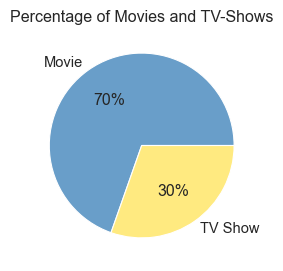

In [48]:
plt.figure(figsize=(3, 3))

plt.pie(x=x_vals, labels=y_vals, colors=["#699ec9", "#ffea80"], autopct="%1.0f%%")
plt.title("Percentage of Movies and TV-Shows")

plt.show()

It looks like Netflix has more than double the number of Movies compared to TV shows. 


##### 2. Feature `Country`

In [49]:
fltr = nf_df["ctry_count"] == 1
content_count = nf_df.loc[fltr, "country"].value_counts().reset_index(name="count")
top_10_ctry = content_count.head(10)
top_10_ctry

,country,count
0,UnitedStates,2844
1,India,1026
2,UnitedKingdom,424
3,Japan,253
4,SouthKorea,200
5,Canada,183
6,Spain,146
7,France,126
8,Egypt,113
9,Mexico,111


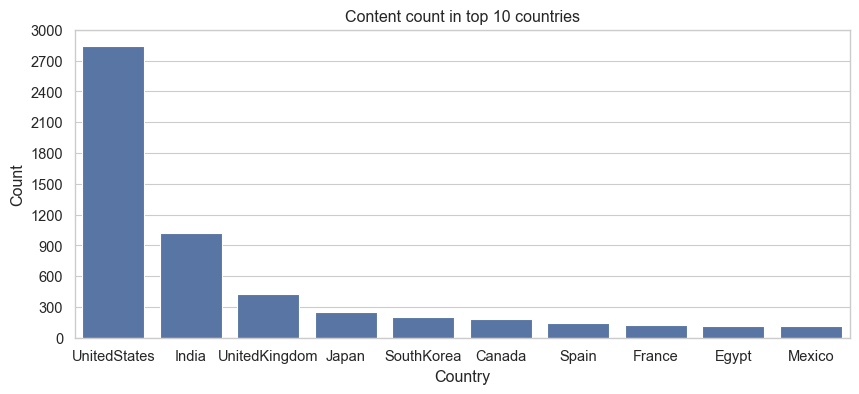

In [50]:
plt.figure(figsize=(10, 4))

sns.barplot(x=top_10_ctry["country"], y=top_10_ctry["count"])
plt.xlabel("Country")
plt.ylabel("Count")
plt.yticks(range(0, 3300, 300))
plt.title("Content count in top 10 countries")

plt.show()

Content ratio between USA and remaining countries. 

In [51]:
fltr = content_count["country"] == "UnitedStates"
others_df = pd.DataFrame(
    data=[["Others", content_count[~fltr]["count"].sum()]],
    columns=["country", "count"],
)
us_vs_others_df = pd.concat((content_count[fltr], others_df), ignore_index=True)
us_vs_others_df

,country,count
0,UnitedStates,2844
1,Others,3946


In [52]:
x_vals = us_vs_others_df["count"]
y_vals = us_vs_others_df["country"]

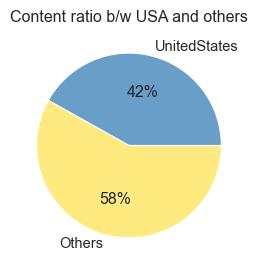

In [53]:
plt.figure(figsize=(3, 3))
plt.pie(x=x_vals, labels=y_vals, colors=["#699ec9", "#ffea80"], autopct="%1.0f%%")
plt.title("Content ratio b/w USA and others")
plt.show()

42% of Netflix's content is produced in the USA. Remaining 58% is produced by the rest of the countries.

In [54]:
fltr = nf_df["ctry_count"] > 1
nf_df.loc[fltr, "country"].value_counts().head(10).reset_index()

,country,count
0,"UnitedKingdom, UnitedStates",123
1,"Canada, UnitedStates",120
2,"Belgium, France",31
3,"China, HongKong",30
4,"Germany, UnitedStates",30
5,"Japan, UnitedStates",28
6,"Mexico, UnitedStates",27
7,"France, UnitedStates",26
8,"Australia, UnitedStates",24
9,"India, UnitedStates",19


In [55]:
colab_count = dict()


def count_country(c_name):
    """
    Function to count number of times a country was collaborated.
    """
    if c_name is not None:
        colab_count[c_name] = colab_count.get(c_name, 0) + 1


fltr = nf_df["ctry_count"] > 1
ctry_colab = nf_df.loc[fltr, "country"].str.split(",", expand=True)
ctry_colab.map(count_country)

colab_df = pd.DataFrame(data=colab_count.items(), columns=["country", "count"])
colab_df.sort_values(by="count", ascending=False).head(10)

,country,count
94,UnitedStates,877
99,UnitedKingdom,267
4,Canada,249
3,France,145
88,France,128
7,UnitedKingdom,124
90,Germany,90
0,Belgium,80
15,China,77
105,Spain,77


##### 3. Feature `rating`

In [56]:
nf_df["rating"].value_counts()

rating
TV-MA    3210
TV-14    2161
TV-PG     863
R         800
PG-13     490
TV-Y7     341
TV-Y      308
PG        287
TV-G      261
NR         86
Name: count, dtype: int64

In [57]:
fltr = nf_df["rating"] != "NR"
slices = nf_df.loc[fltr, "rating"].value_counts()

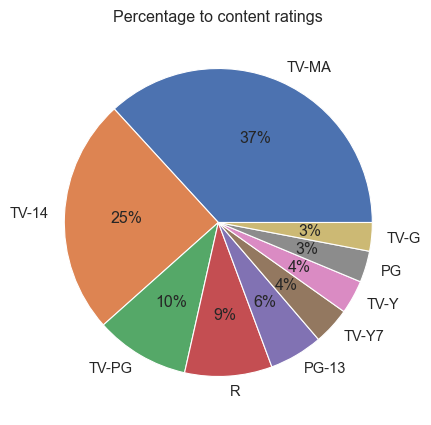

In [58]:
plt.figure(figsize=(5, 5))

plt.pie(x=slices, labels=slices.index, autopct="%1.0f%%")
plt.title("Percentage to content ratings")

plt.show()

In [59]:
fltr = nf_df["content_level"].notna()
slices = nf_df.loc[fltr, "content_level"].value_counts()

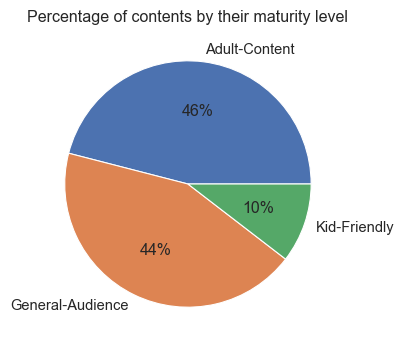

In [60]:
plt.figure(figsize=(4, 4))

plt.pie(x=slices, labels=slices.index, autopct="%1.0f%%")
plt.title("Percentage of contents by their maturity level")

plt.show()

Netflix has only 10% of its contents suitable for kids. Majority of it, around 46%, are suitable for adults. Overall, 54% of the content is suitable for the general audience.

##### 4. Feature `listed_in`

Identify common genre in the content using word cloud.

In [61]:
stop_words = ["international", "independent", "movies", "tv", "shows", "&"]

# Prepare text for word cloud.
genre_text = " ".join(nf_df["listed_in"].str.replace(",", "").tolist())
genres = [word for word in genre_text.split() if word.lower() not in stop_words]
genre_text = " ".join(genres)

# Build word cloud.
genre_wc = WordCloud(width=800, height=400, background_color="white").generate(genre_text)

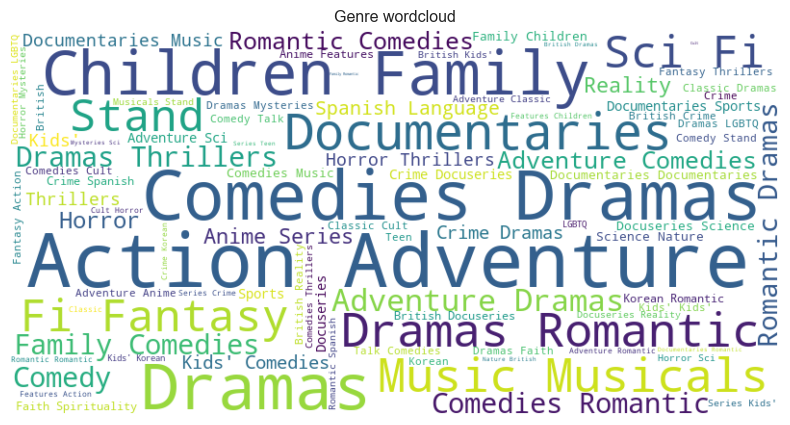

In [62]:
plt.figure(figsize=(10, 5))

plt.imshow(genre_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Genre wordcloud")

plt.show()

Some common genres found are Action, Adventure, Comedies, Dramas, and Documentaries as seen in the above word cloud.


Find common genres between Movies and TV-Shows using word cloud.

In [63]:
fltr = nf_df["type"] == "Movie"

# Prepare text for word cloud.
movg_text = " ".join(nf_df.loc[fltr, "listed_in"].str.replace(",", "").tolist())
mov_genres = [word for word in movg_text.split() if word.lower() not in stop_words]
movg_text = " ".join(mov_genres)

tvsg_text = " ".join(nf_df.loc[~fltr, "listed_in"].str.replace(",", "").tolist())
tvs_genres = [word for word in tvsg_text.split() if word.lower() not in stop_words]
tvsg_text = " ".join(tvs_genres)

# Build word cloud.
movg_wc = WordCloud(width=800, height=400, background_color="white").generate(movg_text)
tvsg_wc = WordCloud(width=800, height=400, background_color="white").generate(tvsg_text)

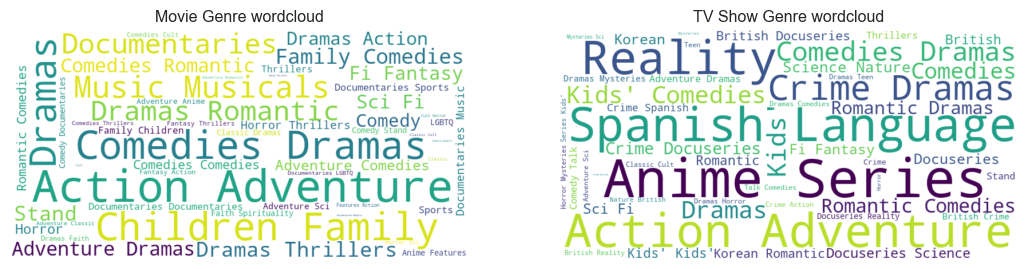

In [64]:
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.imshow(movg_wc, interpolation="bilinear")
plt.axis("off")
plt.title("Movie Genre wordcloud")

plt.subplot(1, 2, 2)
plt.imshow(tvsg_wc, interpolation="bilinear")
plt.axis("off")
plt.title("TV Show Genre wordcloud")

plt.show()

Popular genres in Movies: Action, Adventure, Comedies, Dramas, Family content, Documentaries, etc.
Popular genres in TV-Shows: Action, Adventure, Anime Series, Comedies, Dramas, Crime, Reality, etc.


#### 4.2 Numerical Features

##### 1. Feature `date_added`

In [65]:
fltr = nf_df["date_added"].notna()
da_srs = nf_df.loc[fltr, "date_added"]

pv_df = pd.crosstab(index=da_srs.dt.month.astype(int), columns=da_srs.dt.year.astype(int))

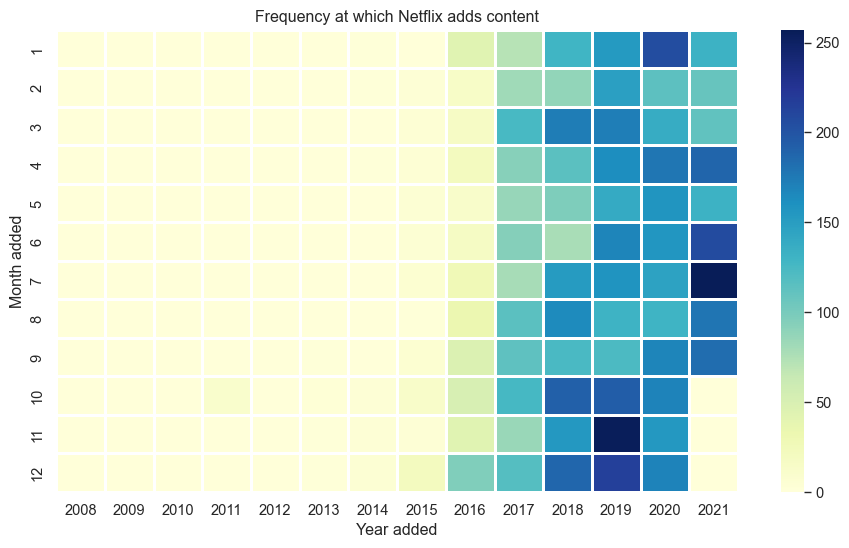

In [66]:
plt.figure(figsize=[11, 6])

sns.heatmap(pv_df, cmap="YlGnBu", linecolor="white", linewidth=1)
plt.xlabel("Year added")
plt.ylabel("Month added")
plt.title("Frequency at which Netflix adds content")

plt.show()

*Observations*: There are no significant patterns on how Netflix refreshes `date_added` in its library. In the last quarter, Netflix has added more content to its platform. 


##### 2. Feature `release_year`

In [67]:
ry_stats = nf_df["release_year"].describe()
ry_stats

count    8807.000000
mean     2014.178267
std         8.818469
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64

In [68]:
latest_content = int(ry_stats["max"].item())
oldest_content = int(ry_stats["min"].item())

print(f"Content for release year varies between ({oldest_content}, {latest_content}).")

Content for release year varies between (1925, 2021).


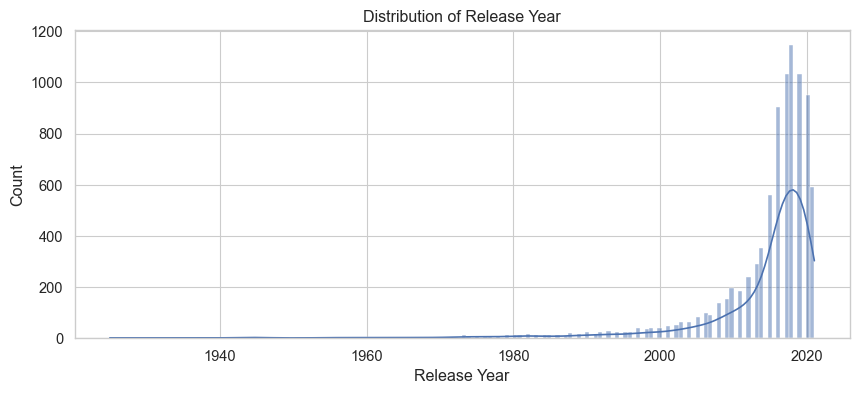

In [69]:
plt.figure(figsize=(10,4))

sns.histplot(data=nf_df, x="release_year", kde=True)
plt.xlabel("Release Year")
plt.title("Distribution of Release Year")

plt.show()

Most of the content available on Netflix was released after the year 2000

##### 3. Feature `duration`

In [70]:
fltr = nf_df["duration_in_min"] != -1
nf_df.loc[fltr, "duration_in_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_in_min, dtype: float64

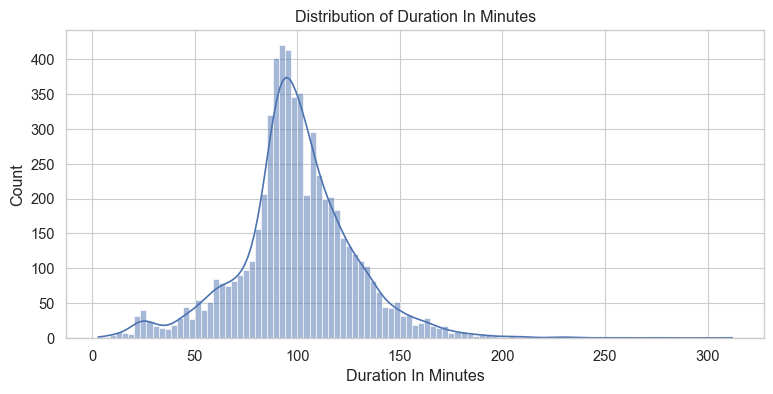

In [71]:
plt.figure(figsize=(9,4))

sns.histplot(data=nf_df[fltr], x="duration_in_min", kde=True)
plt.xlabel("Duration In Minutes")
plt.title("Distribution of Duration In Minutes")

plt.show()

In [72]:
duration_in_hrs = [-1, 60, 120, 180, 240, 300, 360]
duration_labels = [1, 2, 3, 4, 5, 6]
fltr = nf_df["duration_in_min"] != -1

nf_df["duration_in_hrs"] = pd.cut(
    nf_df.loc[fltr, "duration_in_min"],
    bins = duration_in_hrs,
    labels = duration_labels
)

nf_df["duration_in_hrs"].value_counts().reset_index(name="count")

,duration_in_hrs,count
0,2,4502
1,3,1095
2,1,487
3,4,44
4,5,2
5,6,1


Plot a boxplot graph after discarding the outliers with any duration greater than 4 hours. 

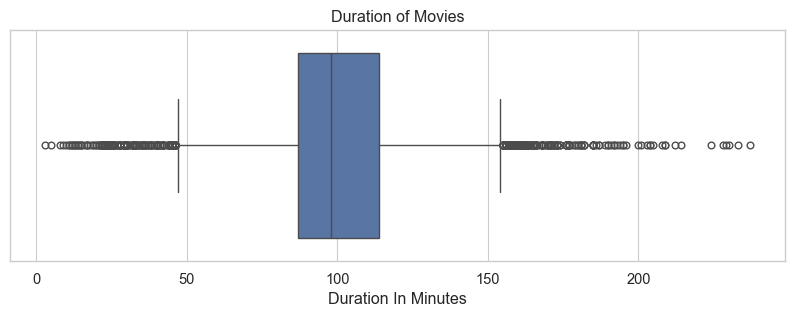

In [73]:
plt.figure(figsize=(10,3))

fltr = (nf_df["duration_in_min"] != -1) & (nf_df["duration_in_hrs"] < 5)
sns.boxplot(data = nf_df[fltr], x = "duration_in_min")
plt.xlabel("Duration In Minutes")
plt.title("Duration of Movies")

plt.show()

#### 4.3 High Cardinality Features

##### 1. Feature `title`

Identify common words used in titles using WordCloud.

In [74]:
# Prepare text for Word Cloud
title_text = " ".join(nf_df["title"].tolist())

# Build Word Cloud
title_wc = WordCloud(width = 800, height = 400, background_color = "white").generate(title_text)

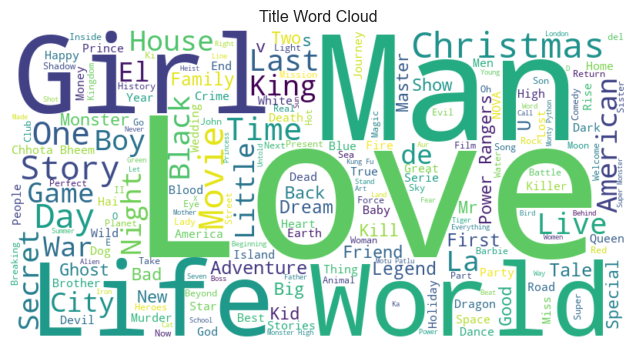

In [75]:
plt.figure(figsize=(8, 4))

plt.imshow(title_wc, interpolation = "bilinear")
plt.axis("off")
plt.title("Title Word Cloud")

plt.show()

In [76]:
# Prepare text for Word Cloud
mov_text = " ".join(nf_df.loc[nf_df["type"] == "Movie", "title"].tolist())
tvs_text = " ".join(nf_df.loc[nf_df["type"] == "TV Show", "title"].tolist())

# Build Word Cloud
mov_wc = WordCloud(width = 800, height = 400, background_color = "white").generate(mov_text)
tvs_wc = WordCloud(width = 800, height = 400, background_color = "white").generate(tvs_text)

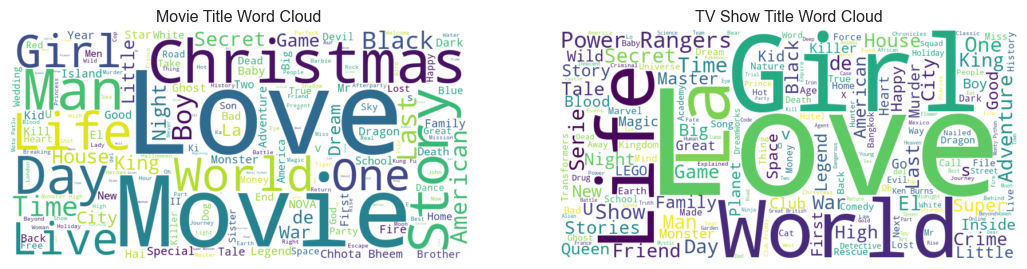

In [77]:
plt.figure(figsize=(13, 6))

plt.subplot(1, 2, 1)
plt.imshow(mov_wc, interpolation = "bilinear")
plt.axis("off")
plt.title("Movie Title Word Cloud")

plt.subplot(1, 2, 2)
plt.imshow(tvs_wc, interpolation = "bilinear")
plt.axis("off")
plt.title("TV Show Title Word Cloud")

plt.show()

The most common word used in the titles of Movie/TV Shows is "Love". 

##### 2. Feature `director`

In [78]:
top_dirs = (
    nf_df.groupby("director")
    .agg(count=("title", "count"))
    .reset_index()
    .sort_values(by="count", ascending=False)
    .head(10)
)
top_dirs

,director,count
1866,"JanSuter, RaúlCampos",19
3469,RajivChilaka,19
2706,MarcusRaboy,16
4066,SuhasKadav,16
1910,JayKaras,14
765,CathyGarcia-Molina,13
1907,JayChapman,12
2773,MartinScorsese,12
4469,YoussefChahine,12
4044,StevenSpielberg,11


In [79]:
# Top 10 Directors in TV Shows

fltr = nf_df["type"] == "TV Show"

top_tvs_dirs = (
    nf_df[fltr]
    .groupby(["director"])
    .agg(count=("title", "count"))
    .reset_index()
    .sort_values(by="count", ascending=False)
    .head(5)
)
top_tvs_dirs

,director,count
8,AlastairFothergill,3
88,IginioStraffi,2
86,HsuFu-chun,2
196,ShinWon-ho,2
201,StanLathan,2


In [80]:
# Movies with most number of directors

fltr = nf_df["dir_count"] == 10
nf_df.loc[fltr, ["title", "director", "country", "release_year", "dir_count"]]

,title,director,country,release_year,dir_count
3485,Sturgill Simpson Presents Sound & Fury,"ArthellIsom, ElsaNakamichi, HajimeSasaki, Henr...",UnitedStates,2019,10.0
6624,Don Quixote: The Ingenious Gentleman of La Mancha,"AlanaWaksman, AustinKolodney, BrandonSomerhald...",UnitedStates,2015,10.0
7164,Kahlil Gibran's The Prophet,"BillPlympton, GaëtanBrizzi, JoanC.Gratz, Joann...","Canada, France, Lebanon, Qatar, UnitedStates",2014,10.0


##### 3. Feature `cast`

Directors who worked with the same cast the most number of times.

In [81]:
dir_fav_cast_df = (
    nf_df.groupby(["director", "type", "cast"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
    .head(10)
)
dir_fav_cast_df

,director,type,cast,count
4196,RajivChilaka,Movie,"JignaBhardwaj, JulieTejwani, Mousam, RajeshKav...",12
4257,RathindranRPrasad,Movie,"AishwaryaRajesh, AvantikaVandanapu, Madhuri, P...",4
4546,S.S.Rajamouli,Movie,"AnushkaShetty, Nassar, Prabhas, RamyaKrishnan,...",4
1466,EdwardCotterill,Movie,RachaelStirling,3
3042,LouisC.K.,Movie,LouisC.K.,3
179,AlastairFothergill,TV Show,DavidAttenborough,3
540,AshwinSaravanan,Movie,"AnishKuruvilla, DavidSolomonRaja, ParvathiT, R...",3
599,B.V.NandiniReddy,Movie,"Aishwarya, JagapathiBabu, Lakshmi, NagaShourya...",3
2254,JayKaras,Movie,BillBurr,3
3539,MikeGunther,Movie,"Bertrand-XavierCorbi, ChrisMulkey, FernandoChi...",3


Skipping the first three rows since they're the same content, but in different languages. It is interesting that Edward Cotterill casted Rachael Stirling three times in movies he's directed. 

### 5. Bivariate Analysis

Under Bivariate Analysis, let's analyze the following combination of features:
1. Categorical vs. Categorical
2. Categorical vs. Numerical
3. Numerical vs. Numerical

#### 5.1 Categorical vs. Categorical

##### 1. Feature `rating` vs. `type`

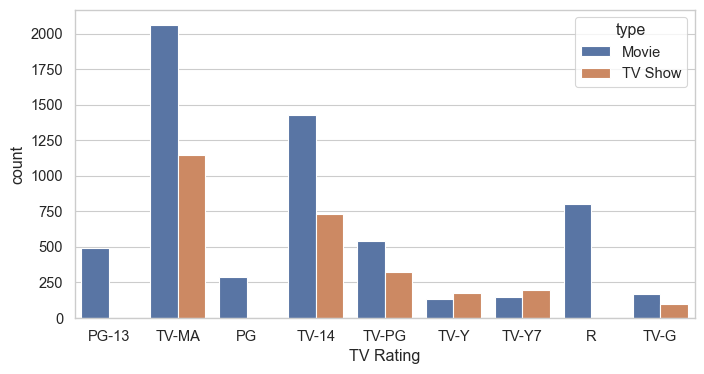

In [82]:
fltr = nf_df["rating"] != "NR"  # Not Rated.

plt.figure(figsize=(8, 4))
sns.countplot(data=nf_df[fltr], x="rating", hue="type")
plt.xlabel("TV Rating")

plt.show()

There's a higher number of kid-friendly (TV-7, TV-Y7) TV Shows available than Movies. Some ratings are specific to Movies, like PG-13 and R, hence no count for TV Shows. 

##### 2. Feature `country` vs. `rating`

In [83]:
top_5_countries = ["UnitedStates", "India", "UnitedKingdom", "Japan", "SouthKorea"]

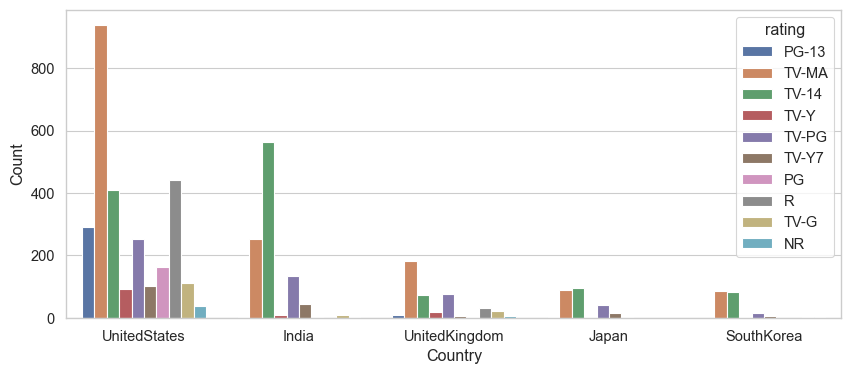

In [84]:
plt.figure(figsize=(10, 4))

fltr = (nf_df["rating"] != "NA") & (nf_df["country"].isin(top_5_countries))
sns.countplot(data=nf_df[fltr], x="country", hue="rating")
plt.xlabel("Country")
plt.ylabel("Count")

plt.show()

Since the rating system is followed in the US & UK, they have the most content variety in every category. The rest of the countries have less rating variety and can be better visualized in the graphs below.

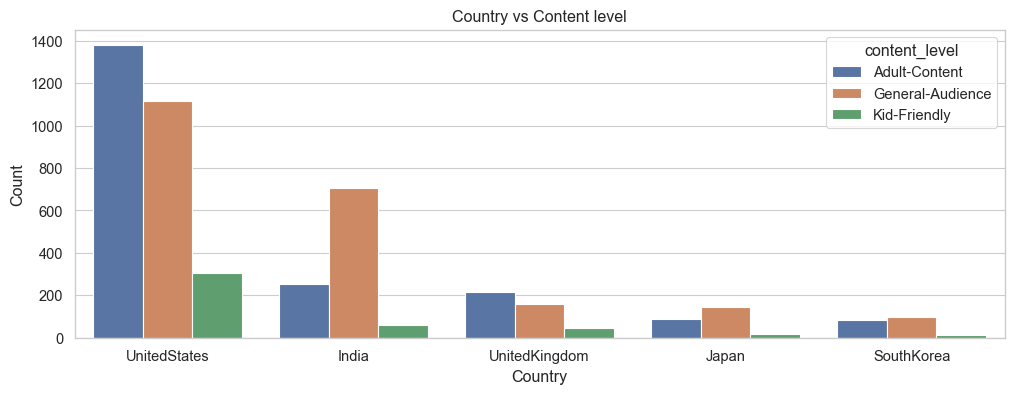

In [85]:
plt.figure(figsize=(12, 4))

fltr = nf_df["country"].isin(top_5_countries)
sns.countplot(data=nf_df[fltr], x="country", hue="content_level")
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Country vs Content level")

plt.show()

The US & UK both produce the most Adult rated content. India, Japan and South Korea mainly produce content that's suitable for the general audience.

##### 3. Features `country` vs. `type`

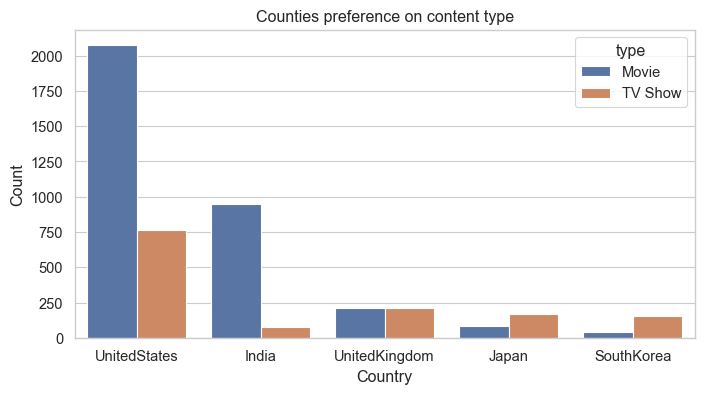

In [86]:
plt.figure(figsize=(8, 4))

fltr = nf_df["country"].isin(top_5_countries)
sns.countplot(data=nf_df[fltr], x="country", hue="type")
plt.xlabel("Country")
plt.ylabel("Count")
plt.title("Counties preference on content type")

plt.show()

The US & India prefer Movies to TV Shows. Japan & South Korea prefer TV Shows to Movies. The UK is split on Movies and TV Shows.

##### 4. Features `country` vs. `listed_in`

In [87]:
# Top 3 genres in Top 5 countries

fltr = nf_df["country"].isin(top_5_countries)

# Fetch popular genres
pop_genres = nf_df[fltr].groupby(["country"])["listed_in"].value_counts().reset_index()

# Fetch top 3 popular genres
top_3_genres = pop_genres.groupby(["country"]).head(3)
top_3_genres.sort_values(by=["country", "count"], ascending=[True, False])

,country,listed_in,count
0,India,"Comedies, Dramas, International Movies",121
1,India,"Dramas, International Movies",119
2,India,"Dramas, Independent Movies, International Movies",108
92,Japan,"Anime Series, International TV Shows",75
93,Japan,"Action & Adventure, Anime Features, Internatio...",32
94,Japan,"Anime Series, Kids' TV",12
148,SouthKorea,"International TV Shows, Korean TV Shows, Roman...",63
149,SouthKorea,"Crime TV Shows, International TV Shows, Korean...",20
150,SouthKorea,"International TV Shows, Korean TV Shows, TV Dr...",18
185,UnitedKingdom,Documentaries,41


International Movies, Dramas, and Comedies are the most common genre among the content produced in India. Japan is a huge of anime content. South Korea prefers TV Shows over Movies. The US & UK both produce the most number of Documentaries amongst the top 5 countries. 

In [88]:
fltr = nf_df["country"].isin(top_5_countries)

pop_genre = (
    nf_df[fltr]
    .groupby(["country", "listed_in"])
    .agg(count=("title", "count"))
    .reset_index()
    .sort_values(by=["country", "count"], ascending=False)
)

top_genre = pop_genre.drop_duplicates(subset=["country"], keep="first")
top_genre

,country,listed_in,count
442,UnitedStates,Documentaries,250
239,UnitedKingdom,Documentaries,41
169,SouthKorea,"International TV Shows, Korean TV Shows, Roman...",63
112,Japan,"Anime Series, International TV Shows",75
31,India,"Comedies, Dramas, International Movies",121


#### 5.2 Categorical vs. Numerical

##### 1. Features `release_year` vs. `country`

Number of movies released by the top 5 countries over the years.

In [89]:
release_history = (
    nf_df[nf_df["country"].isin(top_5_countries)]
    .groupby(["country"])["release_year"]
    .value_counts()
    .reset_index(name="count")
)

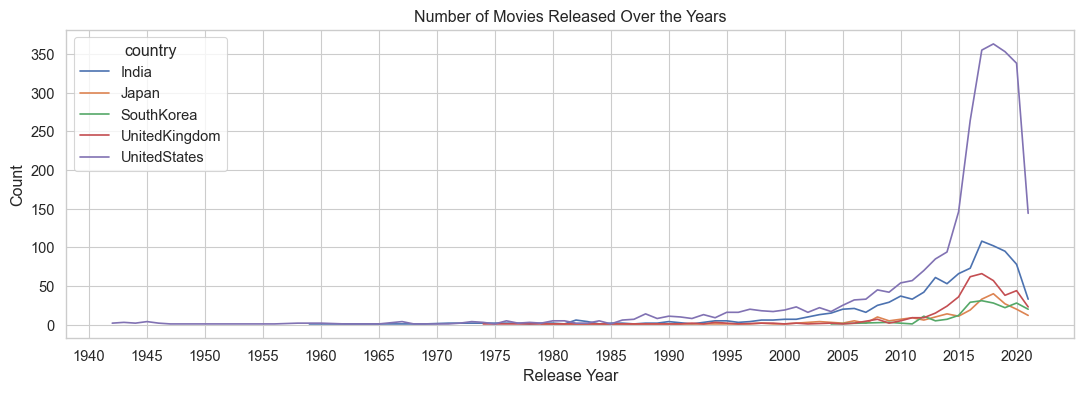

In [90]:
plt.figure(figsize=(13, 4))

sns.lineplot(data=release_history, x="release_year", y="count", hue="country")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Number of Movies Released Over the Years")
plt.xticks(range(1940, 2025, 5))

plt.show()

Let's zoom in on the last 20 years.

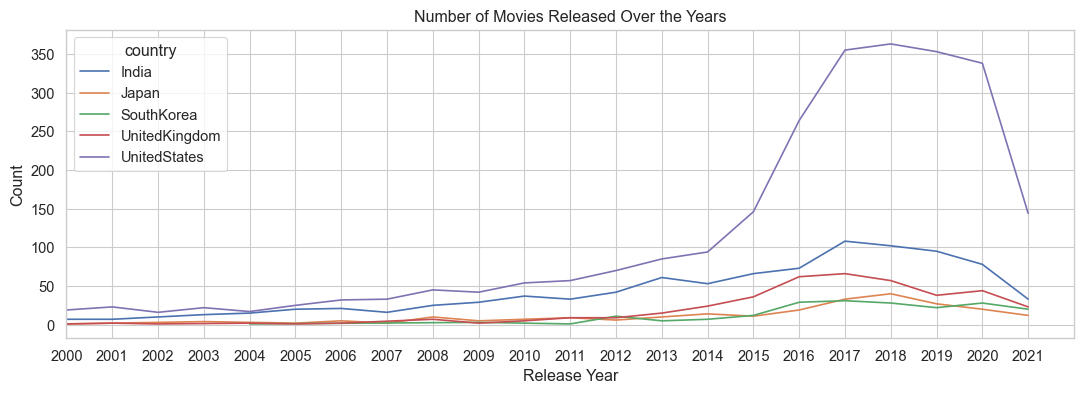

In [91]:
plt.figure(figsize=(13, 4))

sns.lineplot(data=release_history, x="release_year", y="count", hue="country")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Number of Movies Released Over the Years")
plt.xticks(range(2000, 2022))
plt.xlim(left=2000, right=2022)

plt.show()

In the pre-pandemic years, India was **3 years behind** in the number of movies it released compared to the US. The pandemic might have pushed Hollywood back 6 years. Post 2020, there was a sharp decline in the number of movies released (except for South Korea). They're the only country among the top 5 that did not have a major impact in movie releases during the pandemic. 

##### 2. Features `release_year` vs. `type`

Type of content (Movies vs. TV Shows) released over the decade.

In [92]:
release_decade = [0, 1980, 1990, 2000, 2010, 2020, 2030]
release_dlables = ["<1980", "1981-90", "1991-00", "2001-10", "2011-20", ">2021"]
nf_df["release_decade"] = pd.cut(nf_df["release_year"], bins=release_decade, labels=release_dlables)

Type of content (Movies vs. TV Shows) released over 5 year periods (quinquennium).

In [93]:
release_quinq = [0, 2000, 2005, 2010, 2015, 2020, 2025]
release_qlables = ["<2000", "2001-05", "2006-10", "2011-15", "2016-20", ">2020"]
nf_df["release_quinq"] = pd.cut(nf_df["release_year"], bins=release_quinq, labels=release_qlables)

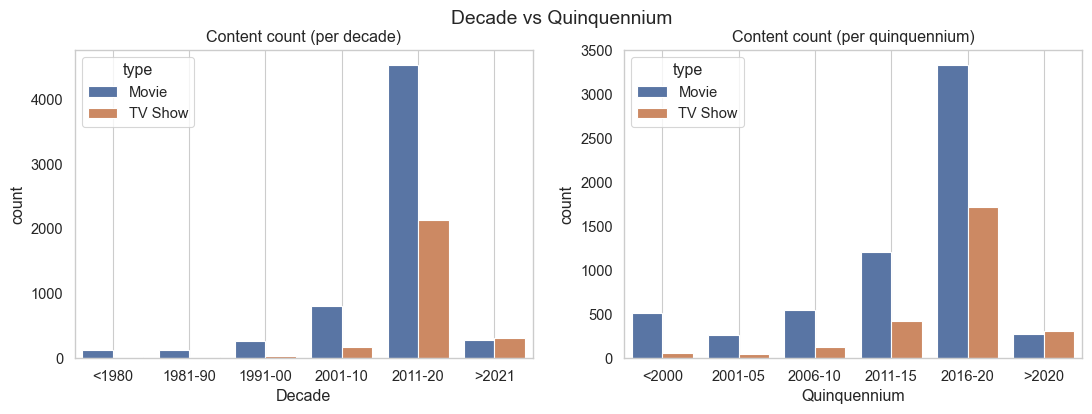

In [94]:
# Decade vs. Quinquennium

plt.figure(figsize=(13, 4))
plt.suptitle("Decade vs Quinquennium")

plt.subplot(1, 2, 1)
sns.countplot(data=nf_df, x="release_decade", hue="type")
plt.xlabel("Decade")
plt.title("Content count (per decade)")
plt.grid()

plt.subplot(1, 2, 2)
sns.countplot(data=nf_df, x="release_quinq", hue="type")
plt.xlabel("Quinquennium")
plt.title("Content count (per quinquennium)")
plt.grid()

plt.show()

The number of TV Shows released has grown significantly over the decades (most likely due to the shift in binge/streaming culture). The 2016-2020 period saw the highest number of TV Show releases.

Trend of content type (Movies vs TV Shows) released over the years.

In [95]:
ry_count_df = nf_df.groupby(["release_year"])["type"].value_counts().reset_index(name="count")

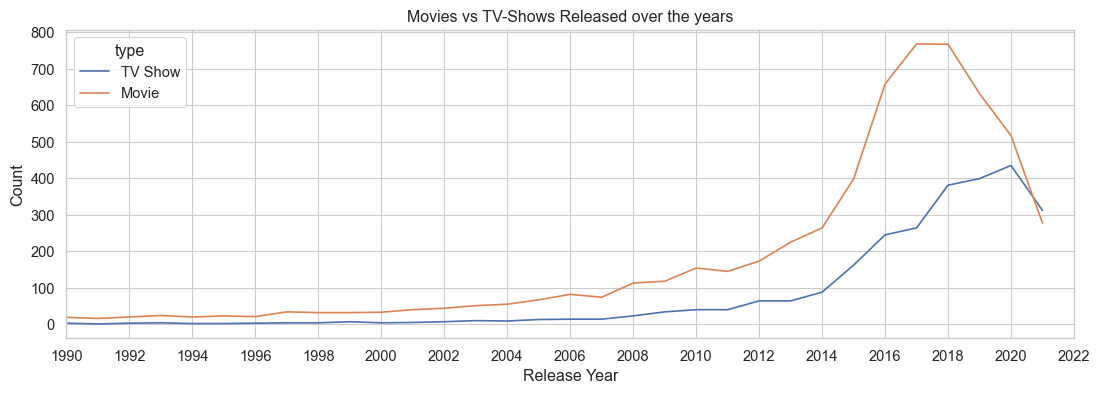

In [96]:
plt.figure(figsize=(13, 4))

sns.lineplot(data=ry_count_df, x="release_year", y="count", hue="type")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Movies vs TV-Shows Released over the years")
plt.xticks(range(1990, 2024, 2))
plt.xlim(left=1990, right=2022)

plt.show()

##### 3. Features `data_added` vs. `type`

Trend of content (Movie vs TV Shows) added to Netflix over the years.

In [97]:
ya_count_df = nf_df.groupby(nf_df["year_added"])["type"].value_counts().reset_index(name="count")

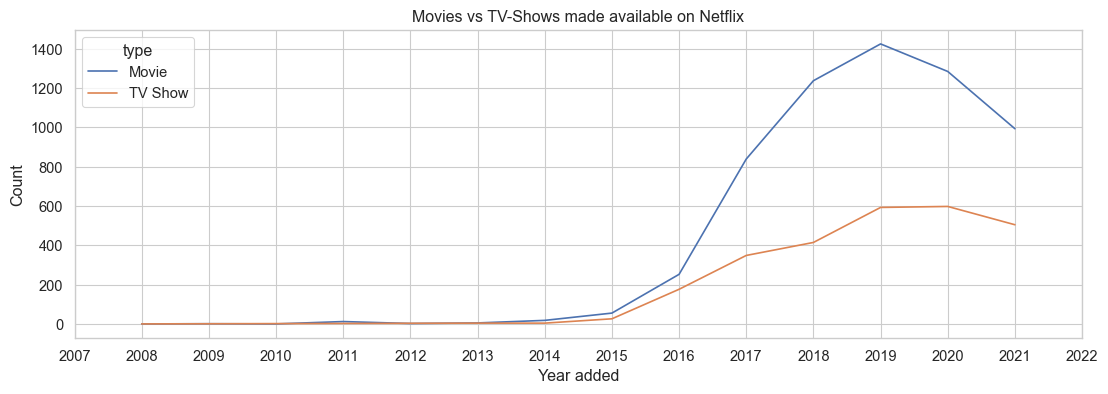

In [98]:
plt.figure(figsize=(13, 4))

sns.lineplot(data=ya_count_df, x="year_added", y="count", hue="type")
plt.xlabel("Year added")
plt.ylabel("Count")
plt.title("Movies vs TV-Shows made available on Netflix")
plt.xticks(range(2007, 2024))
plt.xlim(left=2007, right=2022)

plt.show()

Since 2016, Netflix has been adding more Movies compared to TV Shows. 

Release Trend vs. Streaming Trend

In [99]:
fltr1 = nf_df["release_year"] > 2006
ryc_df = (
    nf_df[fltr1].groupby(nf_df["release_year"])["type"].value_counts().reset_index(name="count")
)

In [100]:
fltr2 = nf_df["release_year"] > 2006
yac_df = nf_df[fltr2].groupby(nf_df["year_added"])["type"].value_counts().reset_index(name="count")

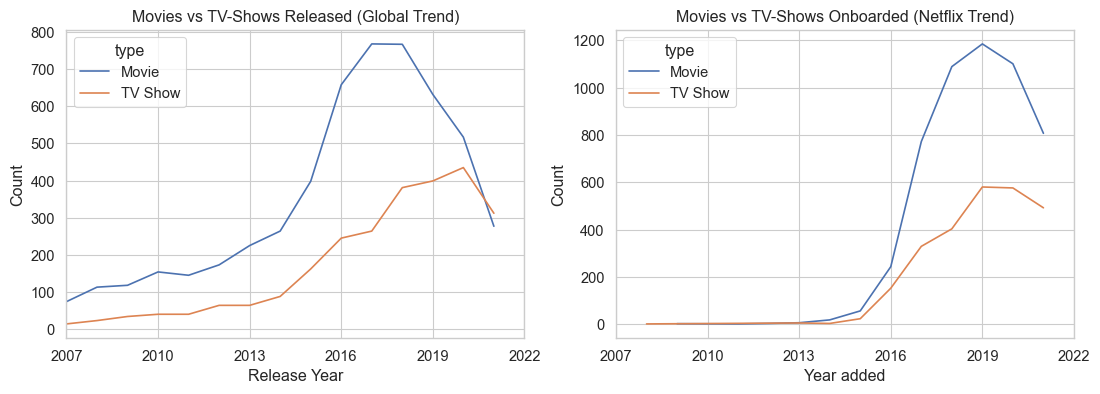

In [101]:
plt.figure(figsize=(13, 4))
ho_mtv = ["Movie", "TV Show"]

plt.subplot(1, 2, 1)
sns.lineplot(data=ryc_df, x="release_year", y="count", hue="type", hue_order=ho_mtv)
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Movies vs TV-Shows Released (Global Trend)")
plt.xticks(range(2007, 2023, 3))
plt.xlim(left=2007, right=2022)

plt.subplot(1, 2, 2)
sns.lineplot(data=yac_df, x="year_added", y="count", hue="type", hue_order=ho_mtv)
plt.xlabel("Year added")
plt.ylabel("Count")
plt.title("Movies vs TV-Shows Onboarded (Netflix Trend)")
plt.xticks(range(2007, 2023, 3))
plt.xlim(left=2007, right=2022)

plt.show()

Until 2015, the rate at which Movies and TV Shows were released did not match with the rate at which Netflix was onboarding its content. Since 2015, Netflix has been onboarding large number of Movies compared to TV Shows and keeping up with global consumption. 

##### 4. Features `release_year` vs. `content_level`

Content rate released over the last 5 years.

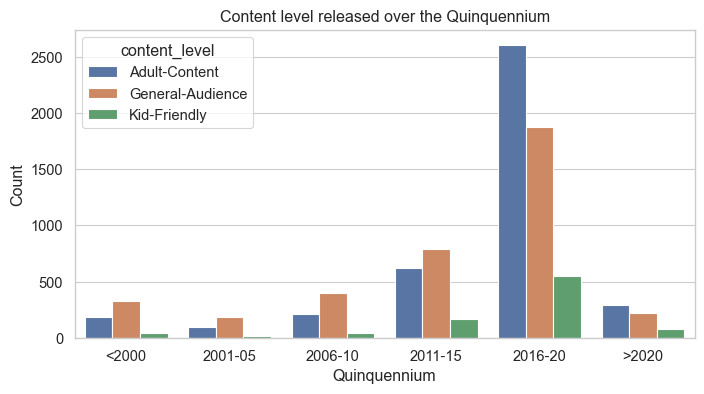

In [102]:
plt.figure(figsize=(8, 4))

sns.countplot(data=nf_df, x="release_quinq", hue="content_level")
plt.xlabel("Quinquennium")
plt.ylabel("Count")
plt.title("Content level released over the Quinquennium")

plt.show()

In [103]:
fltr = nf_df["release_year"] > 2006
cl_ry_df = (
    nf_df[fltr]
    .groupby(["release_year", "content_level"], observed=False)
    .agg(count=("title", "count"))
    .reset_index()
)

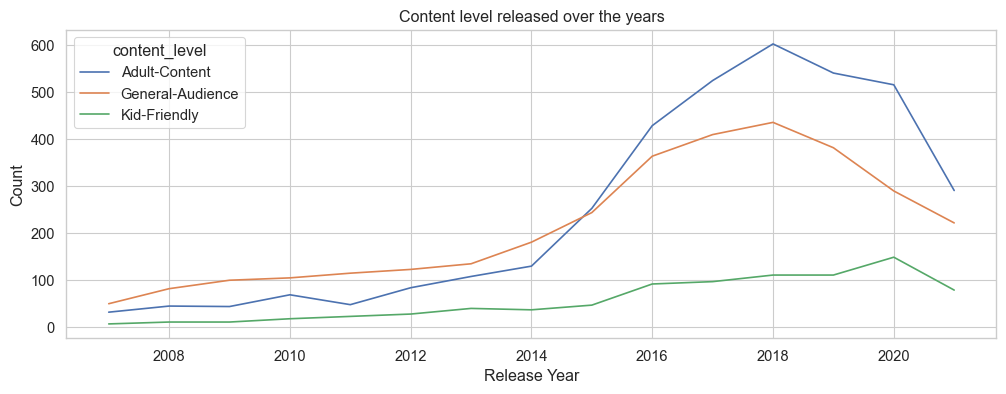

In [104]:
plt.figure(figsize=(12, 4))

sns.lineplot(data=cl_ry_df, x="release_year", y="count", hue="content_level")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Content level released over the years")

plt.show()

##### 5. Features `year_added` vs. `content_level`

In [105]:
fltr = nf_df["release_year"] > 2006
cl_ya_df = (
    nf_df[fltr]
    .groupby(["year_added", "content_level"], observed=False)
    .agg(count=("title", "count"))
    .reset_index()
)

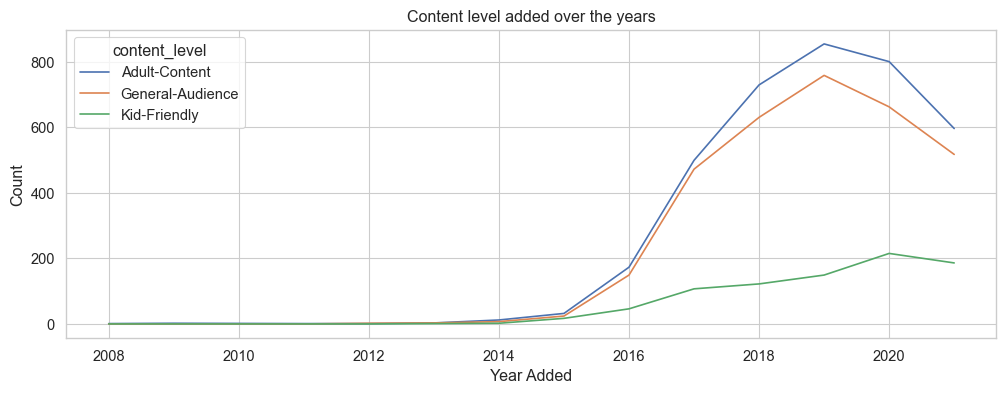

In [106]:
plt.figure(figsize=(12, 4))

sns.lineplot(data=cl_ya_df, x="year_added", y="count", hue="content_level")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.title("Content level added over the years")

plt.show()

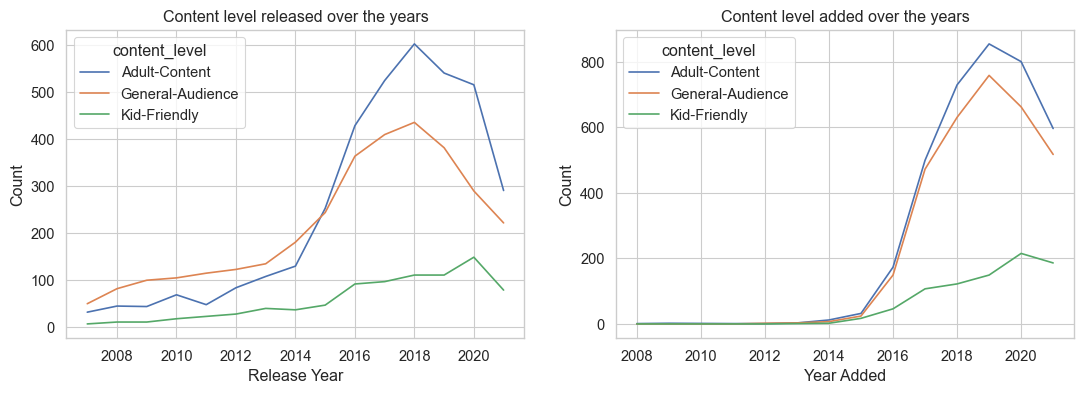

In [107]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=cl_ry_df, x="release_year", y="count", hue="content_level")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.title("Content level released over the years")

plt.subplot(1, 2, 2)
sns.lineplot(data=cl_ya_df, x="year_added", y="count", hue="content_level")
plt.xlabel("Year Added")
plt.ylabel("Count")
plt.title("Content level added over the years")

plt.show()

Netflix is maintaining a healthy balance between content suitable for the general audience and adult content. Although, Netflix has not added as much kid-friendly content compared to General Audience/Adult level content.

#### 5.3 Numerical vs. Numerical

##### 1. Features `release_year` vs. `duration`

Duration of content over the years.

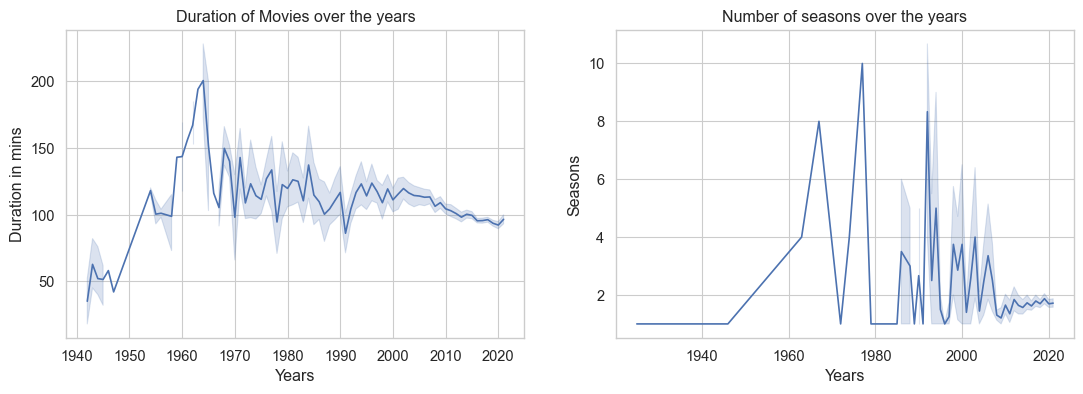

In [108]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
fltr1 = nf_df["duration_in_min"] != -1
sns.lineplot(data=nf_df[fltr1], x="release_year", y="duration_in_min")
plt.xlabel("Years")
plt.ylabel("Duration in mins")
plt.title("Duration of Movies over the years")

plt.subplot(1, 2, 2)
fltr2 = nf_df["duration_in_ssn"] != -1
sns.lineplot(data=nf_df[fltr2], x="release_year", y="duration_in_ssn")
plt.xlabel("Years")
plt.ylabel("Seasons")
plt.title("Number of seasons over the years")

plt.show()

Let's zoom in on the last 20 years.

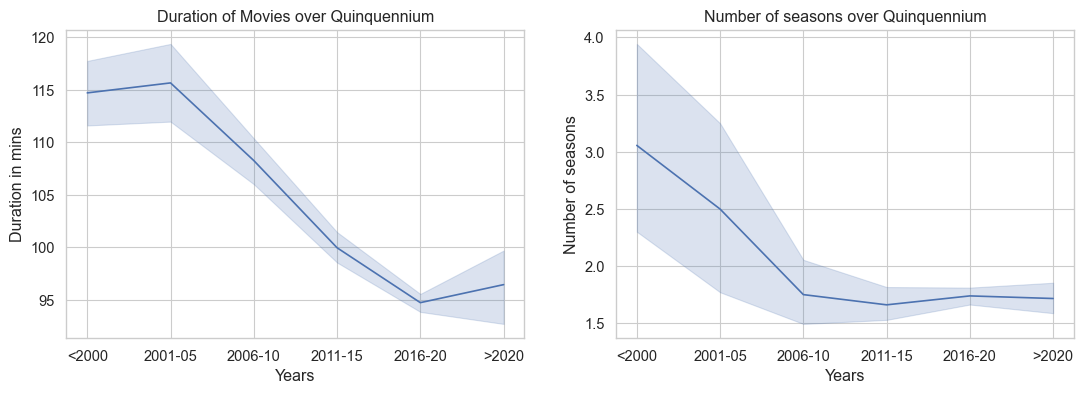

In [109]:
plt.figure(figsize=(13, 4))

plt.subplot(1, 2, 1)
sns.lineplot(data=nf_df[fltr1], x="release_quinq", y="duration_in_min")
plt.xlabel("Years")
plt.ylabel("Duration in mins")
plt.title("Duration of Movies over Quinquennium")

plt.subplot(1, 2, 2)
sns.lineplot(data=nf_df[fltr2], x="release_quinq", y="duration_in_ssn")
plt.xlabel("Years")
plt.ylabel("Number of seasons")
plt.title("Number of seasons over Quinquennium")

plt.show()

Over the years (1940-2021), the average duration of Movies stayed consistent. In the last two decades though, the average duration has been declining, with current average duration being ~95 minutes. From 1960-2021, the average number of seasons of TV Shows were consistent. However, in the last two decades, the average has fallen to 1 season per TV Show. 

##### Features `release_year` vs. `date_added`

Netflix started its online streaming service since 2007.

Lets observe the delay (difference between release year `release_year` and streaming year (`date_added`)) in onboarding content onto Netflix since its release.

In [110]:
fltr = (nf_df["year_added"] > 2006) & (nf_df["release_year"] > 2006)

st_df = nf_df[fltr].copy()  # Streaming DataFrame
st_df["delay"] = st_df["year_added"] - st_df["release_year"]

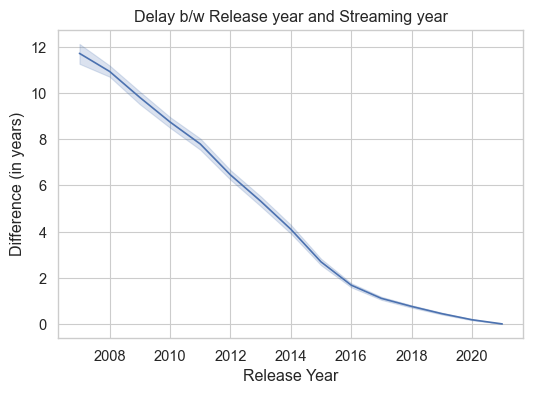

In [111]:
plt.figure(figsize=(6, 4))

sns.lineplot(data=st_df, x="release_year", y="delay")
plt.xlabel("Release Year")
plt.ylabel("Difference (in years)")
plt.title("Delay b/w Release year and Streaming year")

plt.show()

Over the years, there has been a significant fall in the delay of onboarding new content onto Netflix (which is great). Since 2016, Netflix has been offering the latest content on its streaming platform.

### 6. Multivariate Analysis

Under Multivariate Analysis, let's analyze the following combinations of features:
1. Numerical vs. Numerical vs. Categorical
2. Categorical vs. Categorical vs. Numerical
3. Numerical vs. Numerical vs. Numerical

#### 6.1 Numerical vs. Numerical vs. Categorical

##### 1. Features `release_year` vs. `cast_count` vs. `type`

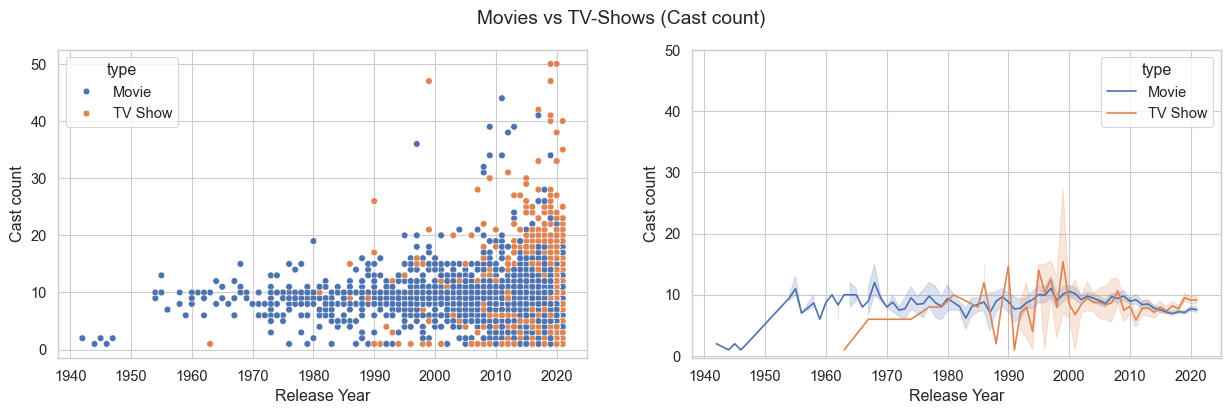

In [112]:
plt.figure(figsize=(15, 4))
plt.suptitle("Movies vs TV-Shows (Cast count)")

plt.subplot(1, 2, 1)
sns.scatterplot(data=nf_df, x="release_year", y="cast_count", hue="type")
plt.xlabel("Release Year")
plt.ylabel("Cast count")

plt.subplot(1, 2, 2)
sns.lineplot(data=nf_df, x="release_year", y="cast_count", hue="type")
plt.xlabel("Release Year")
plt.ylabel("Cast count")
plt.yticks(range(0, 60, 10))

plt.show()

TV Shows have a higher cast count compared to Movies. Over the years, the number of casts (popular) in TV Shows have been increasing, however, the movies have remained consistent in the number of popular casts.

##### 2. Features `release_year` vs. `date_added` vs. `type`

Let's observe the delay in onboarding a Movie vs. TV Show onto Netflix since its release.

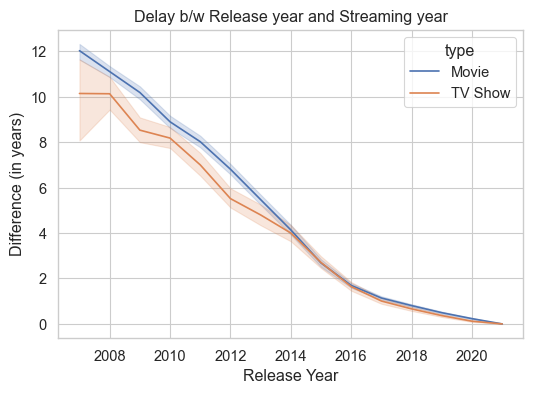

In [113]:
plt.figure(figsize=(6, 4))

sns.lineplot(data=st_df, x="release_year", y="delay", hue="type")
plt.xlabel("Release Year")
plt.ylabel("Difference (in years)")
plt.title("Delay b/w Release year and Streaming year")

plt.show()

TV Shows are onboarded sooner after its release compared to Movies.

### 7. Conclusion

Let's conclude thE EDA by summarizing the Business Insights and Recommendations.

#### 7.1 Business Insights

The summary of business insights derived from the above EDA is listed below:

1. Interesting Patterns
2. Content Insights
3. Market/Demographic Insights

##### Interesting Patterns

1. Since 2007, Netflix's inception of streaming service, the difference between release year and streaming year have drastically reduced, indicating that Netflix is offering the latest content to its viewers almost immediately.
2. Netflix is maintaining a healthy balance between the content suitable for General Audience and Adult rated content, but it has added a much lower number of kid-friendly content over the years.
3. The pandemic might have pushed back Hollywood production by 6 years.
4. South Korea did not have a major impact in Movie releases during the pandemic.
5. TV Shows are onboarded a lot sooner after its release compared to Movies. 

##### Content Insights

1. The Netflix library is made up of 70% Movies and 30% TV Shows.
2. Since 2015, Netflix has been adding more Movies compared to TV Shows.
3. Content Demographics:
   - 46% of Netflix's content are suitable for Adults only. 
   - 54% of Netflix's content are suitable for the General Audience.
   - Only 10% of its library contents are suitable for kids.
4. There is a higher number of kid-friendly (TV-7, TV-Y7) TV Shows that are available compared to Movies.
5. Some common genres found in Netflix's library include:
   - Action Adventure
   - Comedies, Drama
   - Documentaries
   - Dramas
6. Common genres in Movies: Action Adventure, Comedies Drama, Dramas, Family content, Documentaries, etc.
7. Common genres in TV-Shows: Action Adventure, Anime Series, Comedies, Dramas, Crime, Reality, etc.
8. The number of TV-Shows released has grown significantly over the decades.

##### Market / Demographic Insights

1. Based on the library count, Netflix has a major streaming base in the following countries:
   - United States
   - India
   - United Kingdom
   - Japan
   - South Korea
2. 42% of the content is produced in the US and the remaining 58% is produced from the rest of the countries.
3. Countries that collaborated the most number of times are as follows:
   - The UK & US collaborated 123 times.
   - Canada & the US collaborated 120 times.
4. Post pandemic, there has been a significant reduction in movies produced/released by Hollywood.

### 7.2 Recommendations

Since the dataset does not contain any user feedback, these recommendations are mostly based on the content nature on Netflix's platform:

1. Most of Netflix's content is based at its US audience. In order to diversify the market, Netflix must stream more local content depending on the country. As seen post pandemic number of movies produced by USA has drastically reduced. Focusing heavily one market is not sustainable for a business.
2. Content must be tailored to the taste of viewers from different countries.
3. Continue the current strategy of acquiring the latest content with minimal delay between release date and streaming date.
4. Continue the current balance maintained between general Audience content and Adult content, but also increase kid-friendly content.